<a href="https://colab.research.google.com/github/ryanrtrindade/Previsao_Tempo/blob/C%C3%B3digos/construir_modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/python/dataset__chuva_tratado_completo.csv')
df


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,Uluru,2.8,23.4,0.0,4.8,8.4,E,31.0,SE,ENE,...,51.0,24.0,1024.6,1020.3,5.0,5.0,10.1,22.4,No,No
145456,Uluru,3.6,25.3,0.0,4.8,8.4,NNW,22.0,SE,N,...,56.0,21.0,1023.5,1019.1,5.0,5.0,10.9,24.5,No,No
145457,Uluru,5.4,26.9,0.0,4.8,8.4,N,37.0,SE,WNW,...,53.0,24.0,1021.0,1016.8,5.0,5.0,12.5,26.1,No,No
145458,Uluru,7.8,27.0,0.0,4.8,8.4,SE,28.0,SSE,N,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [2]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include = 'object'):

  df[col] = le.fit_transform(df[col])


In [3]:
df

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2,13.4,22.9,0.6,4.8,8.4,13,44.0,13,14,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,0,0
1,2,7.4,25.1,0.0,4.8,8.4,14,44.0,6,15,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,0,0
2,2,12.9,25.7,0.0,4.8,8.4,15,46.0,13,15,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,0,0
3,2,9.2,28.0,0.0,4.8,8.4,4,24.0,9,0,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,0,0
4,2,17.5,32.3,1.0,4.8,8.4,13,41.0,1,7,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,41,2.8,23.4,0.0,4.8,8.4,0,31.0,9,1,...,51.0,24.0,1024.6,1020.3,5.0,5.0,10.1,22.4,0,0
145456,41,3.6,25.3,0.0,4.8,8.4,6,22.0,9,3,...,56.0,21.0,1023.5,1019.1,5.0,5.0,10.9,24.5,0,0
145457,41,5.4,26.9,0.0,4.8,8.4,3,37.0,9,14,...,53.0,24.0,1021.0,1016.8,5.0,5.0,12.5,26.1,0,0
145458,41,7.8,27.0,0.0,4.8,8.4,9,28.0,10,3,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,0,0


In [4]:
df['RainTomorrow'].value_counts()

,count
RainTomorrow,
0,113583
1,31877


In [5]:
from sklearn.model_selection import train_test_split
x = df.drop('RainTomorrow', axis = 1)
y = df['RainTomorrow']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)



In [6]:
!pip install xgboost
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report


import time

In [7]:
modelo_gr = GradientBoostingClassifier(max_depth = 10, max_leaf_nodes= 20, random_state= 42)
modelo_xgb = XGBClassifier(max_depth = 10, max_leaf_nodes= 20, random_state= 42)
modelo_lgb = LGBMClassifier(max_depth = 10, max_leaf_nodes= 20, random_state= 42)

In [8]:
start = time.time()
modelo_gr.fit(x_train, y_train)
end = time.time()
y_pred_train = modelo_gr.predict(x_train)
y_pred_test = modelo_gr.predict(x_test)
print('=================== treino ==================')
print(classification_report(y_train, y_pred_train))
print('=================== teste ==================')
print(classification_report(y_test, y_pred_test))
print(end - start)

=================== treino ==================
              precision    recall  f1-score   support

           0       0.88      0.95      0.92     79596
           1       0.77      0.54      0.63     22226

    accuracy                           0.86    101822
   macro avg       0.82      0.74      0.77    101822
weighted avg       0.86      0.86      0.85    101822

=================== teste ==================
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     33987
           1       0.75      0.52      0.61      9651

    accuracy                           0.86     43638
   macro avg       0.81      0.73      0.76     43638
weighted avg       0.85      0.86      0.85     43638

74.77300119400024


In [9]:
start = time.time()
modelo_xgb.fit(x_train, y_train)
end = time.time()
y_pred_train = modelo_xgb.predict(x_train)
y_pred_test = modelo_xgb.predict(x_test)
print('=================== treino ==================')
print(classification_report(y_train, y_pred_train))
print('=================== teste ==================')
print(classification_report(y_test, y_pred_test))
print(end - start)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:05:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=================== treino ==================
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     79596
           1       0.99      0.89      0.93     22226

    accuracy                           0.97    101822
   macro avg       0.98      0.94      0.96    101822
weighted avg       0.97      0.97      0.97    101822

=================== teste ==================
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     33987
           1       0.73      0.55      0.63      9651

    accuracy                           0.86     43638
   macro avg       0.81      0.75      0.77     43638
weighted avg       0.85      0.86      0.85     43638

13.974817752838135


In [10]:
start = time.time()
modelo_lgb.fit(x_train, y_train)
end = time.time()
y_pred_train = modelo_lgb.predict(x_train)
y_pred_test = modelo_lgb.predict(x_test)
print('=================== treino ==================')
print(classification_report(y_train, y_pred_train))
print('=================== teste ==================')
print(classification_report(y_test, y_pred_test))
print(end - start)

[LightGBM] [Warning] num_leaves is set=31, max_leaf_nodes=20 will be ignored. Current value: num_leaves=31
[LightGBM] [Warning] num_leaves is set=31, max_leaf_nodes=20 will be ignored. Current value: num_leaves=31
[LightGBM] [Info] Number of positive: 22226, number of negative: 79596
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.069473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2634
[LightGBM] [Info] Number of data points in the train set: 101822, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218283 -> initscore=-1.275701
[LightGBM] [Info] Start training from score -1.275701
[LightGBM] [Warning] num_leaves is set=31, max_leaf_nodes=20 will be ignored. Current value: num_leaves=31
[LightGBM] [Warning] num_leaves is set=31, max_leaf_nodes=20 will be ignored. Current value: num_leaves=31
=================== treino ==================
              precision    reca

In [11]:
modelo_previsao = modelo_lgb

In [14]:
from sklearn.model_selection import GridSearchCV

parametros = {'n_estimators':[10,50, 100],
              'learning_rate':[0.1, 1, 10],
              'max_depth':[10,20, 500],
              'max_leaf_nodes':[10,50,100]}


grid = GridSearchCV(estimator = modelo_previsao, param_grid = parametros, cv = 5, scoring = 'f1')

grid.fit(x,y)

A saída de streaming foi truncada nas últimas 5000 linhas.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with po

GridSearchCV(cv=5,
             estimator=LGBMClassifier(max_depth=10, max_leaf_nodes=20,
                                      random_state=42),
             param_grid={'learning_rate': [0.1, 1, 10],
                         'max_depth': [10, 20, 500],
                         'max_leaf_nodes': [10, 50, 100],
                         'n_estimators': [10, 50, 100]},
             scoring='f1')

In [15]:
modelo_lgb = LGBMClassifier(max_depth = 10, max_leaf_nodes= 10, n_estimators=50, random_state= 42)
modelo_lgb.fit(x_train, y_train)

[LightGBM] [Warning] num_leaves is set=31, max_leaf_nodes=10 will be ignored. Current value: num_leaves=31
[LightGBM] [Warning] num_leaves is set=31, max_leaf_nodes=10 will be ignored. Current value: num_leaves=31
[LightGBM] [Info] Number of positive: 22226, number of negative: 79596
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2634
[LightGBM] [Info] Number of data points in the train set: 101822, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218283 -> initscore=-1.275701
[LightGBM] [Info] Start training from score -1.275701


LGBMClassifier(max_depth=10, max_leaf_nodes=10, n_estimators=50,
               random_state=42)

In [16]:
modelo = modelo_lgb

In [17]:
modelo.score(x_train, y_train)


[LightGBM] [Warning] num_leaves is set=31, max_leaf_nodes=10 will be ignored. Current value: num_leaves=31


0.8592642061636975

In [18]:
modelo.score(x_test, y_test)

[LightGBM] [Warning] num_leaves is set=31, max_leaf_nodes=10 will be ignored. Current value: num_leaves=31


0.8545992025299052

In [19]:
erro = 1 - 0.85
print(erro)

0.15000000000000002


In [20]:
modelo.predict_proba(x_test)

[LightGBM] [Warning] num_leaves is set=31, max_leaf_nodes=10 will be ignored. Current value: num_leaves=31


array([[0.37118051, 0.62881949],
       [0.97162941, 0.02837059],
       [0.53649361, 0.46350639],
       ...,
       [0.30455121, 0.69544879],
       [0.95637811, 0.04362189],
       [0.20669938, 0.79330062]])

In [23]:
importantes = pd.DataFrame({
    'Feature': x.columns,
    'Importância': modelo.feature_importances_
})


importantes = importantes.sort_values(
    by = 'Importância',
    ascending = False
)



In [25]:
print(importantes)

          Feature  Importância
15    Pressure3pm          201
13    Humidity3pm          199
0        Location          174
7   WindGustSpeed          151
5        Sunshine          137
17       Cloud3pm           67
3        Rainfall           67
1         MinTemp           66
2         MaxTemp           50
18        Temp9am           48
8      WindDir9am           44
19        Temp3pm           43
9      WindDir3pm           43
14    Pressure9am           43
12    Humidity9am           42
6     WindGustDir           38
11   WindSpeed3pm           34
10   WindSpeed9am           25
4     Evaporation           17
16       Cloud9am           11
20      RainToday            0


<Axes: xlabel='Importância', ylabel='Feature'>

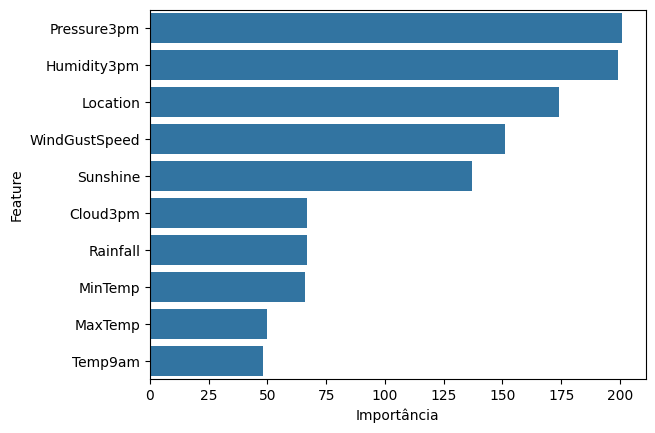

In [29]:
sns.barplot(
    data =importantes.head(10),
    x='Importância',
    y='Feature'
)